In [80]:
# pip install kagglehub[pandas-datasets]

import kagglehub

# Download dataset files locally
path = kagglehub.dataset_download(
    "corrieaar/apartment-rental-offers-in-germany"
)

print(path)

/Users/harshkataria/.cache/kagglehub/datasets/corrieaar/apartment-rental-offers-in-germany/versions/6


In [81]:
import os

print(os.listdir(path))

['immo_data.csv']


In [82]:
# Run this entire block

# pip install -U kagglehub pandas

import shutil
import os
import kagglehub
import pandas as pd

# Clear corrupted KaggleHub cache
cache_dir = os.path.expanduser("~/.cache/kagglehub")

if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

print("Cache cleared.")

# Download dataset manually
path = kagglehub.dataset_download(
    "corrieaar/apartment-rental-offers-in-germany"
)

print("Dataset downloaded to:", path)

# Check files inside dataset
files = os.listdir(path)
print("Files:", files)

# Load CSV file
csv_file = [f for f in files if f.endswith(".csv")][0]

df = pd.read_csv(os.path.join(path, csv_file))

# Show dataset
print(df.head())
print("\nShape:", df.shape)

Cache cleared.


100%|██████████| 93.0M/93.0M [00:03<00:00, 27.1MB/s]

Extracting files...


Dataset downloaded to: /Users/harshkataria/.cache/kagglehub/datasets/corrieaar/apartment-rental-offers-in-germany/versions/6
Files: ['immo_data.csv']
                regio1  serviceCharge                     heatingType  \
0  Nordrhein_Westfalen         245.00                 central_heating   
1      Rheinland_Pfalz         134.00  self_contained_central_heating   
2              Sachsen         255.00                   floor_heating   
3              Sachsen          58.15                district_heating   
4               Bremen         138.00  self_contained_central_heating   

  telekomTvOffer  telekomHybridUploadSpeed  newlyConst  balcony  picturecount  \
0  ONE_YEAR_FREE                       NaN       False    False             6   
1  ONE_YEAR_FREE                       NaN       False     True             8   
2  ONE_YEAR_FREE                      10.0        True     True             8   
3  ONE_YEAR_FREE                       NaN       False     True             9   
4     

In [83]:
import matplotlib.pyplot as plt
# print(df.info())
print(df.describe())


       serviceCharge  telekomHybridUploadSpeed   picturecount     pricetrend  \
count  261941.000000                   45020.0  268850.000000  267018.000000   
mean      151.206113                      10.0       9.791958       3.389001   
std       308.295790                       0.0       6.408399       1.964874   
min         0.000000                      10.0       0.000000     -12.330000   
25%        95.000000                      10.0       6.000000       2.000000   
50%       135.000000                      10.0       9.000000       3.390000   
75%       190.000000                      10.0      13.000000       4.570000   
max    146118.000000                      10.0     121.000000      14.920000   

       telekomUploadSpeed     totalRent  yearConstructed       scoutId  \
count       235492.000000  2.283330e+05    211805.000000  2.688500e+05   
mean            28.804928  9.013315e+02      1966.400590  1.069697e+08   
std             16.337151  3.323833e+04        46.992207 

In [84]:
print(df['totalRent'].describe())
print(df['totalRent'].value_counts().head(10))
# 

count    2.283330e+05
mean     9.013315e+02
std      3.323833e+04
min      0.000000e+00
25%      4.698000e+02
50%      6.500000e+02
75%      9.850000e+02
max      1.575154e+07
Name: totalRent, dtype: float64
totalRent
500.0    1897
450.0    1892
600.0    1805
550.0    1668
400.0    1500
750.0    1495
650.0    1486
800.0    1427
700.0    1417
900.0    1399
Name: count, dtype: int64


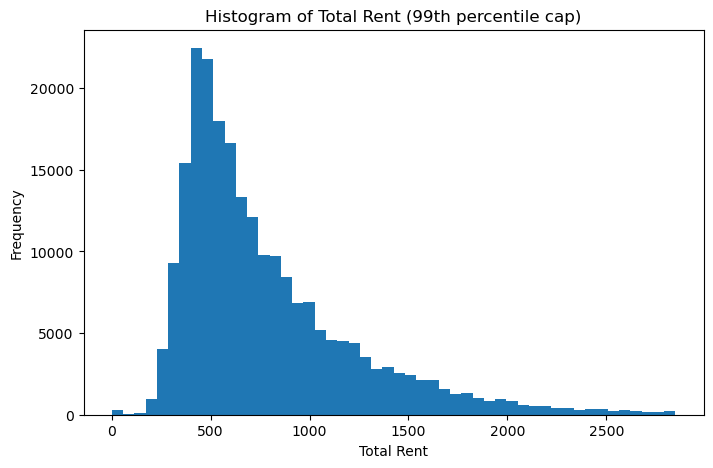

In [85]:
plt.figure(figsize=(8,5))
plt.hist(df['totalRent'].dropna(), bins=50, range=(0, df['totalRent'].quantile(0.99)))
plt.xlabel('Total Rent')
plt.ylabel('Frequency')
plt.title('Histogram of Total Rent (99th percentile cap)')
plt.show()

In [86]:
df.columns

Index(['regio1', 'serviceCharge', 'heatingType', 'telekomTvOffer',
       'telekomHybridUploadSpeed', 'newlyConst', 'balcony', 'picturecount',
       'pricetrend', 'telekomUploadSpeed', 'totalRent', 'yearConstructed',
       'scoutId', 'noParkSpaces', 'firingTypes', 'hasKitchen', 'geo_bln',
       'cellar', 'yearConstructedRange', 'baseRent', 'houseNumber',
       'livingSpace', 'geo_krs', 'condition', 'interiorQual', 'petsAllowed',
       'street', 'streetPlain', 'lift', 'baseRentRange', 'typeOfFlat',
       'geo_plz', 'noRooms', 'thermalChar', 'floor', 'numberOfFloors',
       'noRoomsRange', 'garden', 'livingSpaceRange', 'regio2', 'regio3',
       'description', 'facilities', 'heatingCosts', 'energyEfficiencyClass',
       'lastRefurbish', 'electricityBasePrice', 'electricityKwhPrice', 'date'],
      dtype='object')

In [ ]:
import numpy as np

# remove nulls and outliers
remove_outliers = df[
    df['totalRent'].notna() &
    (df['totalRent'] <= 5000) &
    (df['totalRent'] >= 0)
].copy()

# log transform target
remove_outliers['totalRent_log'] = np.log1p(remove_outliers['totalRent'])
# Features table 
X = remove_outliers.drop(columns=['totalRent', 'totalRent_log']).head()

# Target
y = remove_outliers['totalRent_log'].head()

result_table = remove_outliers[['totalRent', 'totalRent_log']]
# print(result_table.head())
# print(y.head())

numeric_cols     = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric columns:", X[numeric_cols[0]].head())
print("Categorical columns:", categorical_cols)

    


Numeric columns: 0    245.0
2    255.0
4    138.0
6     70.0
7     88.0
Name: serviceCharge, dtype: float64
Categorical columns: ['regio1', 'heatingType', 'telekomTvOffer', 'newlyConst', 'balcony', 'firingTypes', 'hasKitchen', 'geo_bln', 'cellar', 'houseNumber', 'geo_krs', 'condition', 'interiorQual', 'petsAllowed', 'street', 'streetPlain', 'lift', 'typeOfFlat', 'garden', 'regio2', 'regio3', 'description', 'facilities', 'energyEfficiencyClass', 'date']
